In [1]:
# ============================================================
# 1. ИМПОРТЫ, ПУТИ, КОНФИГУРАЦИЯ, СИДЫ
# ============================================================
# Стек: PyTorch + timm (ConvNeXt V2 Tiny + EVA-02 Small)
# + Albumentations (TTA) + scipy (оптимизация весов ансамбля)
# + sklearn (метрики) + seaborn (матрица ошибок)

import gc
import random
import warnings
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy.optimize import minimize

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

import timm
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score,
    classification_report,
    confusion_matrix,
)

warnings.filterwarnings("ignore")

# ── Пути ─────────────────────────────────────────────────────
BASE_DIR         = Path("/kaggle/input/datasets/tkachenko1van/dl-lab-1-image-classification-corrected/dl-lab-1-image-classification-corrected")
TRAIN_DIR        = BASE_DIR / "train" / "train"
TEST_DIR         = BASE_DIR / "test_images" / "test_images"
SAMPLE_SUB       = BASE_DIR / "sample_submission.csv"
WEIGHTS_CONVNEXT = Path("/kaggle/input/datasets/tkachenko1van/convnext-folds")
WEIGHTS_EVA      = Path("/kaggle/input/datasets/tkachenko1van/eva-folds")

# ── Конфигурация ──────────────────────────────────────────────
SEED              = 9999
N_SPLITS          = 5
DEVICE            = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES       = 15
IMG_SIZE_CONVNEXT = 288
IMG_SIZE_EVA      = 280   # кратно patch_size=14

# ── Классы ───────────────────────────────────────────────────
class_to_idx = {
    "Апельсин": 0, "Бананы": 1, "Груши": 2, "Кабачки": 3,
    "Капуста": 4, "Картофель": 5, "Киви": 6, "Лимон": 7,
    "Лук": 8, "Мандарины": 9, "Морковь": 10, "Огурцы": 11,
    "Томаты": 12, "Яблоки зелёные": 13, "Яблоки красные": 14,
}
idx_to_class  = {v: k for k, v in class_to_idx.items()}
CLASS_NAMES   = [idx_to_class[i] for i in range(NUM_CLASSES)]


def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False


set_seed(SEED)
print(f"Device : {DEVICE}  |  CUDA : {torch.cuda.is_available()}")

print("\nПроверка весов моделей:")
for fold_idx in range(1, N_SPLITS + 1):
    p_c = WEIGHTS_CONVNEXT / f"convnext_fold{fold_idx}_stage2.pth"
    p_e = WEIGHTS_EVA      / f"eva_fold{fold_idx}_stage2.pth"
    print(f"  Фолд {fold_idx}: ConvNeXt={'✅' if p_c.exists() else '❌'} | "
          f"EVA={'✅' if p_e.exists() else '❌'}")

Device : cuda  |  CUDA : True

Проверка весов моделей:
  Фолд 1: ConvNeXt=✅ | EVA=✅
  Фолд 2: ConvNeXt=✅ | EVA=✅
  Фолд 3: ConvNeXt=✅ | EVA=✅
  Фолд 4: ConvNeXt=✅ | EVA=✅
  Фолд 5: ConvNeXt=✅ | EVA=✅


In [2]:
# ============================================================
# 2. ТРАНСФОРМЫ (val/test — без аугментаций)
# ============================================================
# Нормализация ImageNet: mean/std соответствуют предобучению обеих моделей.
# Размер: ConvNeXt=288px, EVA=280px (кратно patch_size=14 → 20×20 патчей).

val_transform_convnext = A.Compose([
    A.Resize(IMG_SIZE_CONVNEXT, IMG_SIZE_CONVNEXT),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform_eva = A.Compose([
    A.Resize(IMG_SIZE_EVA, IMG_SIZE_EVA),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# ── Нормализаторы для TTA (без Resize — ресайз делается вручную) ─
_tta_norm_convnext = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

_tta_norm_eva = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])


def _to_tensor_convnext(img: np.ndarray) -> torch.Tensor:
    return _tta_norm_convnext(image=img)["image"].unsqueeze(0)


def _to_tensor_eva(img: np.ndarray) -> torch.Tensor:
    return _tta_norm_eva(image=img)["image"].unsqueeze(0)

In [4]:
# ============================================================
# 3. ДАТАСЕТ И ФОЛДЫ
# ============================================================
# Идентичные seed и параметры с ноутбуками обучения →
# те же индексы фолдов → корректный OOF без data leakage.
# Стратификация по group_key (класс × подпапка): изображения
# одной «камеры» не разделяются между train и val.

def collect_dataframe(train_dir: Path) -> pd.DataFrame:
    records = []
    for class_dir in sorted(train_dir.iterdir()):
        if not class_dir.is_dir():
            continue
        class_name = class_dir.name
        if class_name not in class_to_idx:
            continue
        label = class_to_idx[class_name]
        for sub_dir in sorted(class_dir.iterdir()):
            if not sub_dir.is_dir():
                continue
            group_key = f"{class_name}__{sub_dir.name}"
            for ext in ("*.jpg", "*.jpeg", "*.png"):
                for img_path in sub_dir.glob(ext):
                    records.append({
                        "path"      : str(img_path),
                        "class_name": class_name,
                        "label"     : label,
                        "subfolder" : sub_dir.name,
                        "group_key" : group_key,
                    })
    df = pd.DataFrame(records)
    return df.sample(frac=1, random_state=SEED).reset_index(drop=True)


df_all = collect_dataframe(TRAIN_DIR)

skf   = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
folds = [
    (tr_idx, vl_idx)
    for tr_idx, vl_idx in skf.split(df_all, df_all["group_key"])
]

print(f"\nДатасет: {len(df_all)} изображений | "
      f"{df_all['label'].nunique()} классов | "
      f"{df_all['group_key'].nunique()} групп")
print(f"Фолдов: {N_SPLITS}  (seed={SEED}, стратификация по group_key)")


Датасет: 9819 изображений | 15 классов | 43 групп
Фолдов: 5  (seed=9999, стратификация по group_key)


In [5]:
# ============================================================
# 4. ЗАГРУЗКА МОДЕЛЕЙ
# ============================================================
# Загружаются только обученные веса (Stage 2) без pretrained backbone —
# все параметры уже в файлах весов.

def get_model_convnext() -> nn.Module:
    return timm.create_model(
        "convnextv2_tiny.fcmae_ft_in22k_in1k",
        pretrained=False,
        num_classes=NUM_CLASSES,
    ).to(DEVICE)


def get_model_eva() -> nn.Module:
    return timm.create_model(
        "eva02_small_patch14_336.mim_in22k_ft_in1k",
        pretrained=False,
        num_classes=NUM_CLASSES,
        img_size=IMG_SIZE_EVA,
    ).to(DEVICE)


def load_fold_model(model_name: str, fold: int) -> nn.Module:
    if model_name == "convnext":
        path  = WEIGHTS_CONVNEXT / f"convnext_fold{fold}_stage2.pth"
        model = get_model_convnext()
    else:
        path  = WEIGHTS_EVA / f"eva_fold{fold}_stage2.pth"
        model = get_model_eva()
    model.load_state_dict(
        torch.load(path, map_location=DEVICE, weights_only=True))
    model.eval()
    return model


print("\nЗагрузка моделей (2 архитектуры × 5 фолдов = 10 моделей)...")
convnext_models = [load_fold_model("convnext", f) for f in range(1, N_SPLITS + 1)]
eva_models      = [load_fold_model("eva",      f) for f in range(1, N_SPLITS + 1)]
print(f"  ConvNeXt V2 Tiny : {len(convnext_models)} моделей ✅")
print(f"  EVA-02 Small     : {len(eva_models)} моделей ✅")


Загрузка моделей (2 архитектуры × 5 фолдов = 10 моделей)...
  ConvNeXt V2 Tiny : 5 моделей ✅
  EVA-02 Small     : 5 моделей ✅


In [6]:
# ============================================================
# 5. TTA: ПОСТРОЕНИЕ ВАРИАНТОВ И ИНФЕРЕНС
# ============================================================
# 8 детерминированных TTA-вариантов = 4 геометрии × 2 масштаба:
#   Геометрия: оригинал | HFlip | VFlip | HFlip+VFlip
#   Масштаб  : полный (вес=1.0) | CenterCrop 95%→resize (вес=0.25)
# Зум-варианты имеют меньший вес: объекты крупноплановые,
# кроп может обрезать важные детали на краях кадра.
# ConvNeXt crop_margin = 5% от 288px = ~14px.
# EVA-02     crop_margin = 14px = ровно 1 патч (patch_size=14).

def build_tta_pairs(
    img_rgb    : np.ndarray,
    img_size   : int,
    to_tensor,
    crop_margin: int | None = None,
) -> list[tuple[torch.Tensor, float]]:
    """
    Формирует 8 TTA-пар (тензор, вес) для одного изображения.

    Args:
        img_rgb     : RGB uint8, произвольный размер
        img_size    : целевой размер (288 для ConvNeXt, 280 для EVA)
        to_tensor   : функция нормализации → тензор (1,C,H,W)
        crop_margin : пиксели обрезки с каждой стороны;
                      None → 5% от img_size
    """
    S      = img_size
    margin = crop_margin if crop_margin is not None else int(round(S * 0.05))
    img    = cv2.resize(img_rgb, (S, S), interpolation=cv2.INTER_LINEAR)

    def zoomed(src: np.ndarray) -> np.ndarray:
        c = src[margin:S - margin, margin:S - margin].copy()
        return cv2.resize(c, (S, S), interpolation=cv2.INTER_LINEAR)

    bases = [
        img,
        img[:, ::-1, :].copy(),   # HFlip
        img[::-1, :, :].copy(),   # VFlip
        img[::-1, ::-1, :].copy(),# HFlip + VFlip
    ]
    pairs = []
    for b in bases:
        pairs.append((to_tensor(b),          1.00))
        pairs.append((to_tensor(zoomed(b)),  0.25))
    assert len(pairs) == 8
    return pairs


@torch.no_grad()
def predict_with_tta(
    model: nn.Module,
    pairs: list[tuple[torch.Tensor, float]],
) -> np.ndarray:
    """Взвешенное усреднение softmax по 8 TTA-вариантам."""
    probs, total_w = np.zeros(NUM_CLASSES, np.float32), 0.0
    for t, w in pairs:
        x = t.to(DEVICE, non_blocking=True)
        with torch.amp.autocast("cuda"):
            probs += w * torch.softmax(model(x), dim=1)[0].cpu().numpy()
        total_w += w
    return (probs / total_w).astype(np.float32)


@torch.no_grad()
def get_ensemble_probs(
    img_rgb        : np.ndarray,
    models_convnext: list[nn.Module],
    models_eva     : list[nn.Module],
) -> tuple[np.ndarray, np.ndarray]:
    """
    Вычисляет усреднённые TTA-вероятности для обеих архитектур.

    Returns:
        probs_conv : (NUM_CLASSES,) — среднее по 5 фолдам ConvNeXt
        probs_eva  : (NUM_CLASSES,) — среднее по 5 фолдам EVA-02
    """
    # ConvNeXt: crop_margin = 5% от 288 ≈ 14px
    pairs_conv = build_tta_pairs(
        img_rgb, IMG_SIZE_CONVNEXT, _to_tensor_convnext,
        crop_margin=int(round(IMG_SIZE_CONVNEXT * 0.05)),
    )
    probs_conv = np.zeros(NUM_CLASSES, np.float32)
    for m in models_convnext:
        probs_conv += predict_with_tta(m, pairs_conv)
    probs_conv /= len(models_convnext)

    # EVA-02: crop_margin = 14px = 1 патч (patch_size=14)
    pairs_eva = build_tta_pairs(
        img_rgb, IMG_SIZE_EVA, _to_tensor_eva,
        crop_margin=14,
    )
    probs_eva = np.zeros(NUM_CLASSES, np.float32)
    for m in models_eva:
        probs_eva += predict_with_tta(m, pairs_eva)
    probs_eva /= len(models_eva)

    return probs_conv, probs_eva

In [7]:
# ============================================================
# 6. OOF-ПРЕДСКАЗАНИЯ С TTA
# ============================================================
# Out-of-Fold inference: каждая модель фолда K предсказывает
# только на валидационной части фолда K — данные, которых
# модель не видела при обучении.
# Схема: 2 архитектуры × 5 фолдов × 8 TTA = 80 пассов/изображение.

print(f"\n{'='*60}")
print(f"  OOF-INFERENCE С TTA")
print(f"  2 архитектуры × {N_SPLITS} фолдов × 8 TTA = 80 пассов/изображение")
print(f"  ConvNeXt crop_margin={int(round(IMG_SIZE_CONVNEXT*0.05))}px "
      f"| EVA crop_margin=14px (1 патч)")
print(f"{'='*60}")

oof_probs_convnext = np.zeros((len(df_all), NUM_CLASSES), np.float32)
oof_probs_eva      = np.zeros((len(df_all), NUM_CLASSES), np.float32)
oof_labels         = np.zeros(len(df_all), np.int64)

with torch.inference_mode():
    for fold_idx, (tr_idx, vl_idx) in enumerate(folds):
        val_df = df_all.iloc[vl_idx].reset_index(drop=True)
        m_conv = convnext_models[fold_idx]
        m_eva  = eva_models[fold_idx]

        print(f"\n  Фолд {fold_idx + 1}/{N_SPLITS} — {len(vl_idx)} изображений")

        for i in tqdm(range(len(val_df)), desc=f"  Фолд {fold_idx+1}", leave=False):
            global_idx             = int(vl_idx[i])
            row                    = val_df.iloc[i]
            oof_labels[global_idx] = int(row["label"])

            img_bgr = cv2.imdecode(
                np.fromfile(row["path"], dtype=np.uint8),
                cv2.IMREAD_COLOR,
            )
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

            p_conv, p_eva = get_ensemble_probs(
                img_rgb,
                models_convnext=[m_conv],
                models_eva     =[m_eva],
            )
            oof_probs_convnext[global_idx] = p_conv
            oof_probs_eva[global_idx]      = p_eva

print(f"\n  ✅ OOF завершён: {len(df_all)} изображений размечено")


  OOF-INFERENCE С TTA
  2 архитектуры × 5 фолдов × 8 TTA = 80 пассов/изображение
  ConvNeXt crop_margin=14px | EVA crop_margin=14px (1 патч)

  Фолд 1/5 — 1964 изображений



  Фолд 2/5 — 1964 изображений



  Фолд 3/5 — 1964 изображений



  Фолд 4/5 — 1964 изображений



  Фолд 5/5 — 1963 изображений



  ✅ OOF завершён: 9819 изображений размечено



  OOF-отчёт: ConvNeXt V2 Tiny
  Accuracy        : 0.9614
  F1 macro        : 0.9578
  F1 weighted     : 0.9614

  Класс                    Prec    Rec     F1     N
  ------------------------------------------------
  Апельсин                0.960  0.963  0.961   864
  Бананы                  0.985  0.985  0.985   802
  Груши                   0.944  0.951  0.947   407
  Кабачки                 0.973  0.973  0.973   295
  Капуста                 0.992  0.992  0.992   833
  Картофель               0.945  0.955  0.950   794
  Киви                    0.894  0.889  0.891   189
  Лимон                   0.978  0.973  0.976   675
  Лук                     0.947  0.934  0.940   647
  Мандарины               0.945  0.947  0.946   775
  Морковь                 0.973  0.961  0.967   611
  Огурцы                  0.983  0.990  0.987   592
  Томаты                  0.949  0.952  0.950   776
  Яблоки зелёные          0.975  0.977  0.976   853
  Яблоки красные          0.927  0.924  0.925   706
  --

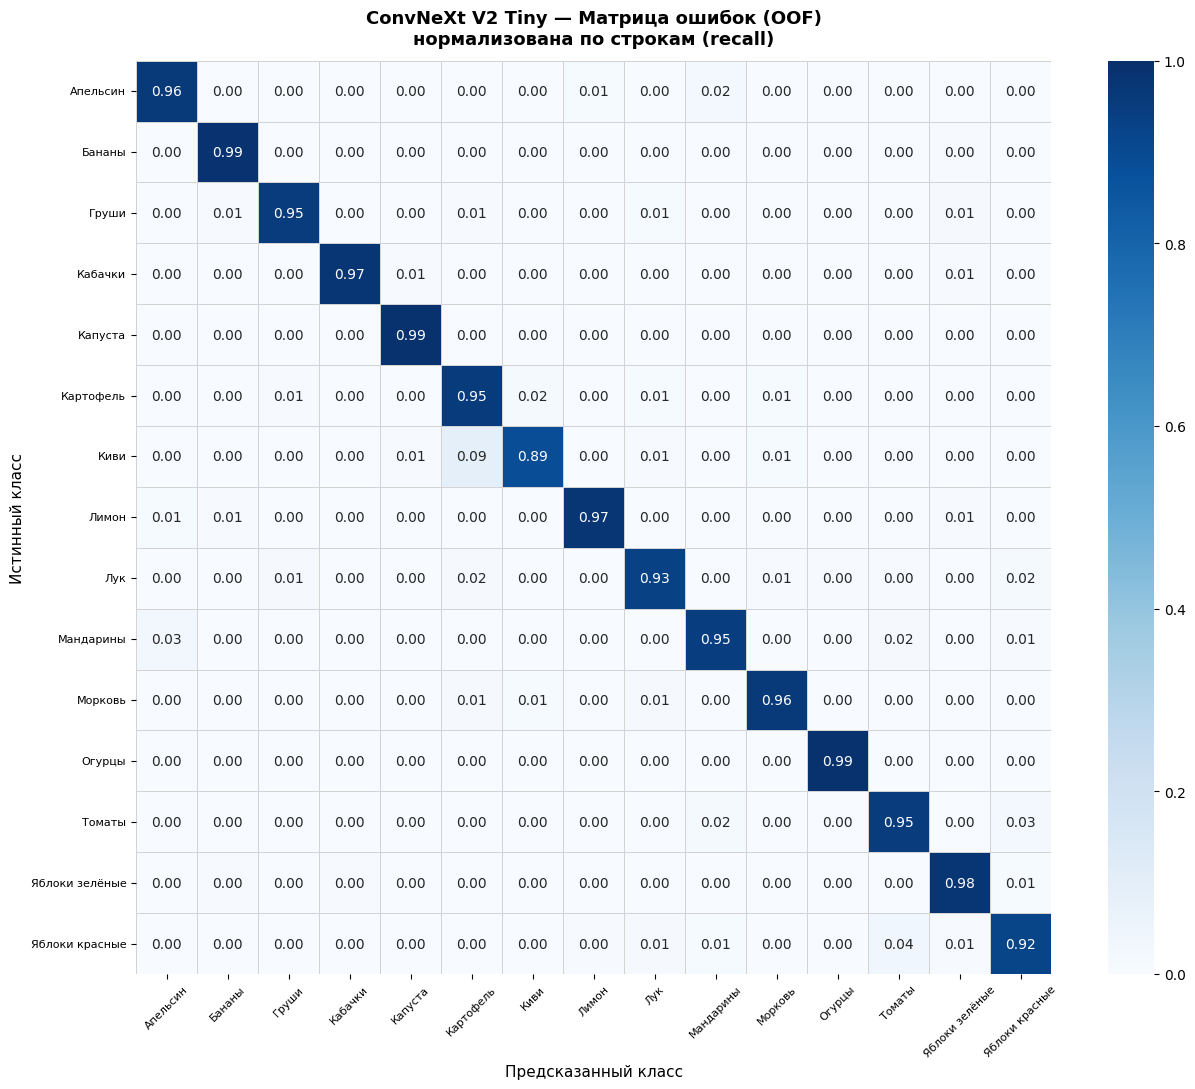

  Матрица сохранена: /kaggle/working/cm_norm_convnext_v2_tiny.png

  OOF-отчёт: EVA-02 Small
  Accuracy        : 0.9542
  F1 macro        : 0.9497
  F1 weighted     : 0.9542

  Класс                    Prec    Rec     F1     N
  ------------------------------------------------
  Апельсин                0.943  0.957  0.950   864
  Бананы                  0.985  0.974  0.979   802
  Груши                   0.925  0.943  0.934   407
  Кабачки                 0.937  0.963  0.950   295
  Капуста                 0.990  0.984  0.987   833
  Картофель               0.944  0.940  0.942   794
  Киви                    0.867  0.894  0.880   189
  Лимон                   0.970  0.964  0.967   675
  Лук                     0.951  0.934  0.942   647
  Мандарины               0.944  0.938  0.941   775
  Морковь                 0.953  0.964  0.959   611
  Огурцы                  0.985  0.990  0.987   592
  Томаты                  0.946  0.948  0.947   776
  Яблоки зелёные          0.965  0.967  0.966 

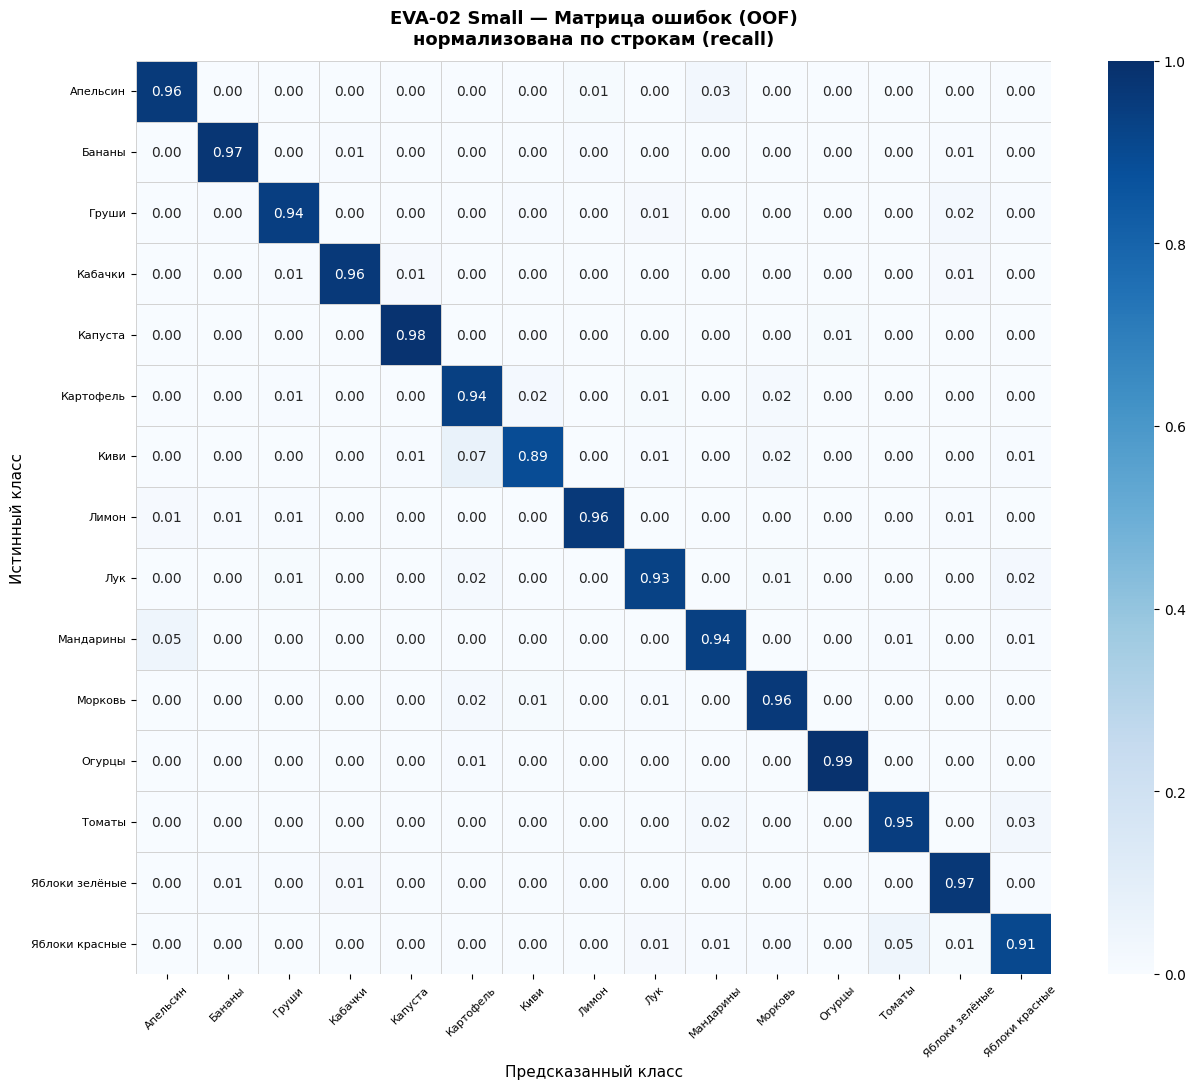

  Матрица сохранена: /kaggle/working/cm_norm_eva-02_small.png

  Сравнение OOF (с TTA):
  Модель                 Accuracy   F1 macro
  ------------------------------------------
  ConvNeXt V2 Tiny         0.9614     0.9578
  EVA-02 Small             0.9542     0.9497


In [8]:
# ============================================================
# 7. OOF-АНАЛИЗ ПО МОДЕЛЯМ
# ============================================================
# Для каждой модели: accuracy, F1 macro/weighted по классам,
# матрица ошибок (confusion matrix) с нормализацией по строкам
# (= recall по классам) — показывает с какими классами путает модель.

def plot_confusion_matrix(
    labels    : np.ndarray,
    preds     : np.ndarray,
    model_name: str,
    normalize : bool = True,
) -> None:
    """
    Строит тепловую карту матрицы ошибок.
    Строки = истинный класс, столбцы = предсказанный класс.
    Нормализация по строкам → диагональ = recall каждого класса.
    """
    cm = confusion_matrix(labels, preds)
    if normalize:
        cm_plot = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
        fmt, vmax = ".2f", 1.0
    else:
        cm_plot = cm.astype(float)
        fmt, vmax = "d", None

    fig, ax = plt.subplots(figsize=(13, 11))
    sns.heatmap(
        cm_plot,
        annot=True,
        fmt=fmt,
        cmap="Blues",
        vmin=0,
        vmax=vmax,
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        linewidths=0.4,
        linecolor="lightgrey",
        ax=ax,
    )
    ax.set_title(
        f"{model_name} — Матрица ошибок (OOF)\n"
        f"{'нормализована по строкам (recall)' if normalize else 'абсолютные значения'}",
        fontsize=13, fontweight="bold", pad=12,
    )
    ax.set_ylabel("Истинный класс", fontsize=11)
    ax.set_xlabel("Предсказанный класс", fontsize=11)
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.tick_params(axis="y", rotation=0,  labelsize=8)
    plt.tight_layout()
    fname = (f"/kaggle/working/cm_"
             f"{'norm_' if normalize else ''}"
             f"{model_name.lower().replace(' ', '_')}.png")
    plt.savefig(fname, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"  Матрица сохранена: {fname}")


def oof_full_report(
    probs     : np.ndarray,
    labels    : np.ndarray,
    model_name: str,
) -> tuple[float, float]:
    """
    Полный OOF-отчёт: метрики + per-class + матрица ошибок.

    Returns:
        (accuracy, f1_macro)
    """
    preds    = probs.argmax(axis=1)
    acc      = (preds == labels).mean()
    f1_mac   = f1_score(labels, preds, average="macro")
    f1_wgt   = f1_score(labels, preds, average="weighted")

    print(f"\n{'='*60}")
    print(f"  OOF-отчёт: {model_name}")
    print(f"  Accuracy        : {acc:.4f}")
    print(f"  F1 macro        : {f1_mac:.4f}")
    print(f"  F1 weighted     : {f1_wgt:.4f}")
    print(f"{'='*60}")

    # ── Per-class метрики ─────────────────────────────────────
    f1_per   = f1_score(labels, preds, average=None)
    from sklearn.metrics import precision_score, recall_score
    prec_per = precision_score(labels, preds, average=None, zero_division=0)
    rec_per  = recall_score(labels, preds, average=None, zero_division=0)

    print(f"\n  {'Класс':<22} {'Prec':>6} {'Rec':>6} {'F1':>6} {'N':>5}")
    print(f"  {'-'*48}")
    for i in range(NUM_CLASSES):
        n_true = (labels == i).sum()
        flag   = " ←" if f1_per[i] < 0.85 else ""
        print(f"  {idx_to_class[i]:<22} {prec_per[i]:>6.3f} "
              f"{rec_per[i]:>6.3f} {f1_per[i]:>6.3f} {n_true:>5}{flag}")
    print(f"  {'-'*48}")
    print(f"  {'macro avg':<22} {prec_per.mean():>6.3f} "
          f"{rec_per.mean():>6.3f} {f1_mac:>6.3f}")

    # ── Топ-5 ошибочных пар (класс → класс) ──────────────────
    cm = confusion_matrix(labels, preds)
    np.fill_diagonal(cm, 0)           # убираем правильные предсказания
    errors = []
    for true_c in range(NUM_CLASSES):
        for pred_c in range(NUM_CLASSES):
            if cm[true_c, pred_c] > 0:
                errors.append((cm[true_c, pred_c], true_c, pred_c))
    errors.sort(reverse=True)

    print(f"\n  Топ-10 ошибочных пар (истинный → предсказанный):")
    print(f"  {'Истинный':<22} {'Предсказанный':<22} {'N':>4}")
    print(f"  {'-'*52}")
    for cnt, tc, pc in errors[:10]:
        print(f"  {idx_to_class[tc]:<22} {idx_to_class[pc]:<22} {cnt:>4}")

    # ── Матрица ошибок ────────────────────────────────────────
    plot_confusion_matrix(labels, preds, model_name, normalize=True)

    return acc, f1_mac


acc_c, f1_c = oof_full_report(oof_probs_convnext, oof_labels, "ConvNeXt V2 Tiny")
acc_e, f1_e = oof_full_report(oof_probs_eva,      oof_labels, "EVA-02 Small")

print(f"\n  Сравнение OOF (с TTA):")
print(f"  {'Модель':<20} {'Accuracy':>10} {'F1 macro':>10}")
print(f"  {'-'*42}")
print(f"  {'ConvNeXt V2 Tiny':<20} {acc_c:>10.4f} {f1_c:>10.4f}")
print(f"  {'EVA-02 Small':<20} {acc_e:>10.4f} {f1_e:>10.4f}")

In [9]:
# ============================================================
# 8. ПОИСК ОПТИМАЛЬНЫХ ВЕСОВ АНСАМБЛЯ
# ============================================================
# Nelder-Mead минимизирует -F1_macro на OOF-вероятностях.
# Начальная точка [1.0, 1.0] — равные веса.
# Веса нормируются: w_conv / (w_conv + w_eva) после оптимизации.
# Сетка равномерного поиска используется для визуализации
# поверхности F1 и проверки глобального оптимума.

def ensemble_f1(weights: np.ndarray) -> float:
    """OOF F1-macro ансамбля с заданными (ненормированными) весами."""
    w_c, w_e = float(weights[0]), float(weights[1])
    if w_c < 0 or w_e < 0:
        return 0.0
    total = w_c + w_e + 1e-9
    probs = (oof_probs_convnext * w_c + oof_probs_eva * w_e) / total
    return f1_score(oof_labels, probs.argmax(axis=1), average="macro")


print(f"\n{'='*60}")
print(f"  ПОИСК ОПТИМАЛЬНЫХ ВЕСОВ АНСАМБЛЯ (Nelder-Mead)")
print(f"{'='*60}")

opt = minimize(
    fun     = lambda w: -ensemble_f1(w),
    x0      = [1.0, 1.0],
    method  = "Nelder-Mead",
    options = {"maxiter": 500, "xatol": 1e-5, "fatol": 1e-5, "disp": False},
)

best_w_conv, best_w_eva = opt.x
total_w     = best_w_conv + best_w_eva
norm_w_conv = best_w_conv / total_w
norm_w_eva  = best_w_eva  / total_w
best_f1     = ensemble_f1(opt.x)
ens_preds   = (
    oof_probs_convnext * norm_w_conv +
    oof_probs_eva      * norm_w_eva
).argmax(axis=1)
best_acc = (ens_preds == oof_labels).mean()

print(f"\n  Оптимальные веса:")
print(f"  ConvNeXt V2 Tiny : {norm_w_conv:.4f}  ({norm_w_conv*100:.1f}%)")
print(f"  EVA-02 Small     : {norm_w_eva:.4f}  ({norm_w_eva*100:.1f}%)")
print(f"\n  OOF F1 macro:")
print(f"    ConvNeXt        : {f1_c:.4f}")
print(f"    EVA-02          : {f1_e:.4f}")
print(f"    Ансамбль        : {best_f1:.4f}  "
      f"(+{best_f1 - max(f1_c, f1_e):.4f} vs лучшей модели)")
print(f"  OOF Accuracy (ансамбль): {best_acc:.4f}")


  ПОИСК ОПТИМАЛЬНЫХ ВЕСОВ АНСАМБЛЯ (Nelder-Mead)

  Оптимальные веса:
  ConvNeXt V2 Tiny : 0.5349  (53.5%)
  EVA-02 Small     : 0.4651  (46.5%)

  OOF F1 macro:
    ConvNeXt        : 0.9578
    EVA-02          : 0.9497
    Ансамбль        : 0.9602  (+0.0025 vs лучшей модели)
  OOF Accuracy (ансамбль): 0.9635



  Построение поверхности F1 по сетке весов...


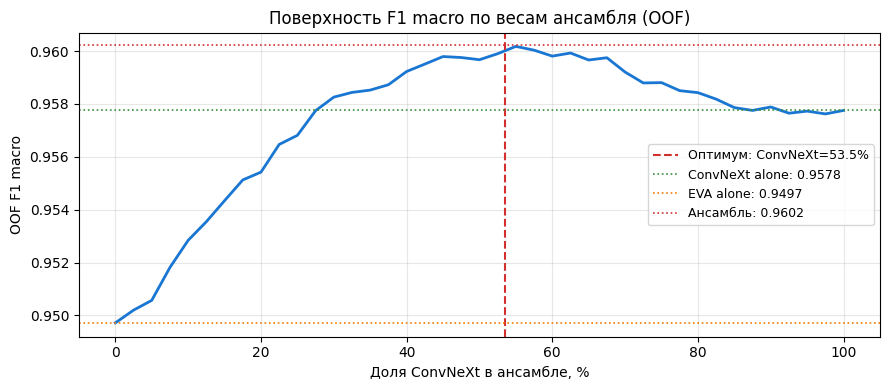

  График сохранён: /kaggle/working/ensemble_f1_surface.png


In [10]:
# ── Визуализация поверхности F1 по сетке весов ───────────────
print("\n  Построение поверхности F1 по сетке весов...")
grid_vals = np.linspace(0.0, 1.0, 41)   # доля ConvNeXt: 0% → 100%
f1_grid   = np.array([
    ensemble_f1([alpha, 1.0 - alpha])
    for alpha in grid_vals
])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(grid_vals * 100, f1_grid, lw=2, color="#1976D2")
ax.axvline(norm_w_conv * 100, color="#D32F2F", ls="--", lw=1.5,
           label=f"Оптимум: ConvNeXt={norm_w_conv*100:.1f}%")
ax.axhline(f1_c, color="#388E3C", ls=":",  lw=1.2,
           label=f"ConvNeXt alone: {f1_c:.4f}")
ax.axhline(f1_e, color="#F57C00", ls=":",  lw=1.2,
           label=f"EVA alone: {f1_e:.4f}")
ax.axhline(best_f1, color="#D32F2F", ls=":", lw=1.2,
           label=f"Ансамбль: {best_f1:.4f}")
ax.set_xlabel("Доля ConvNeXt в ансамбле, %")
ax.set_ylabel("OOF F1 macro")
ax.set_title("Поверхность F1 macro по весам ансамбля (OOF)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/ensemble_f1_surface.png", dpi=120, bbox_inches="tight")
plt.show()
print("  График сохранён: /kaggle/working/ensemble_f1_surface.png")


  OOF-анализ финального ансамбля:

  OOF-отчёт: Ансамбль (оптимальные веса)
  Accuracy        : 0.9635
  F1 macro        : 0.9602
  F1 weighted     : 0.9635

  Класс                    Prec    Rec     F1     N
  ------------------------------------------------
  Апельсин                0.960  0.966  0.963   864
  Бананы                  0.985  0.981  0.983   802
  Груши                   0.954  0.963  0.958   407
  Кабачки                 0.966  0.976  0.971   295
  Капуста                 0.992  0.992  0.992   833
  Картофель               0.945  0.955  0.950   794
  Киви                    0.899  0.894  0.897   189
  Лимон                   0.973  0.973  0.973   675
  Лук                     0.956  0.941  0.949   647
  Мандарины               0.951  0.951  0.951   775
  Морковь                 0.964  0.966  0.965   611
  Огурцы                  0.988  0.990  0.989   592
  Томаты                  0.958  0.952  0.955   776
  Яблоки зелёные          0.973  0.975  0.974   853
  Яблоки к

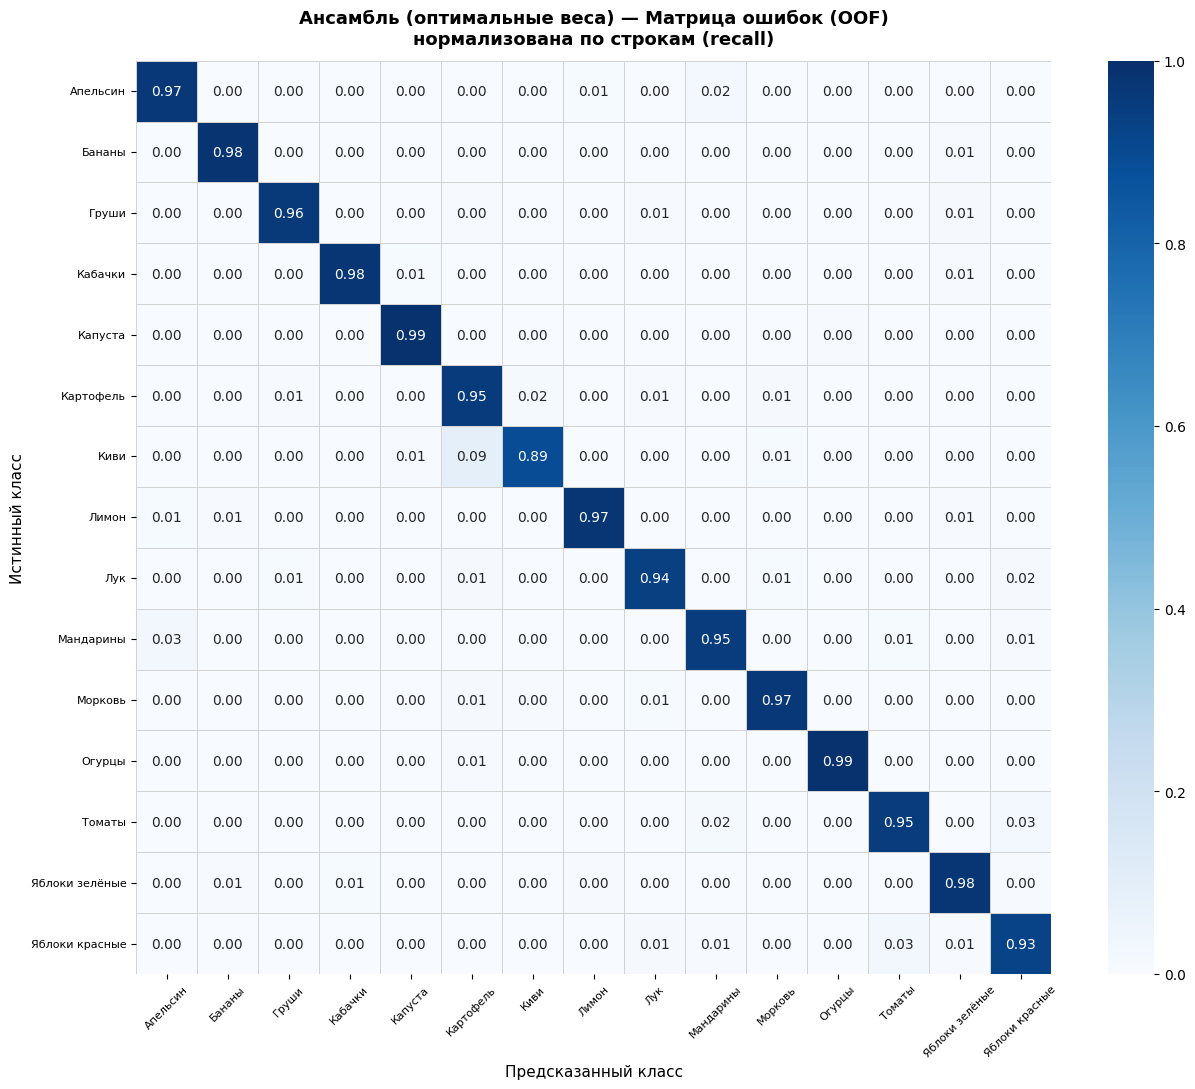

  Матрица сохранена: /kaggle/working/cm_norm_ансамбль_(оптимальные_веса).png


In [11]:
# ── OOF-анализ ансамбля ───────────────────────────────────────
print(f"\n  OOF-анализ финального ансамбля:")
ens_probs = (oof_probs_convnext * norm_w_conv +
             oof_probs_eva      * norm_w_eva)
_, _ = oof_full_report(ens_probs, oof_labels, "Ансамбль (оптимальные веса)")

In [12]:
# ============================================================
# 9. ФИНАЛЬНЫЙ INFERENCE НА ТЕСТОВЫХ ДАННЫХ (взвешенный TTA)
# ============================================================
# Схема: 2 архитектуры × 5 фолдов × 8 TTA = 80 пассов/изображение.
# Каждая архитектура усредняет все 5 фолдов (full ensemble),
# затем взвешенно объединяется по найденным OOF-весам.
# TTA: 4 геометрии × 2 масштаба | веса: оригинал=1.0, зум=0.25.

TTA_N = 8
print(f"\n{'='*60}")
print(f"  ФИНАЛЬНЫЙ INFERENCE (тестовый датасет)")
print(f"  ConvNeXt: {N_SPLITS} фолдов × {TTA_N} TTA = {N_SPLITS*TTA_N} пассов")
print(f"  EVA-02  : {N_SPLITS} фолдов × {TTA_N} TTA = {N_SPLITS*TTA_N} пассов")
print(f"  Итого   : {N_SPLITS*TTA_N*2} форвард-пассов/изображение")
print(f"  Веса    : ConvNeXt={norm_w_conv:.3f} | EVA={norm_w_eva:.3f}")
print(f"  TTA     : 4 геометрии × 2 масштаба (оригинал=1.0, зум=0.25)")
print(f"{'='*60}")

submission  = pd.read_csv(SAMPLE_SUB)
pred_labels = []

for m in convnext_models + eva_models:
    m.eval()

with torch.inference_mode():
    for image_id in tqdm(submission["image_id"], desc="Test inference"):
        img_bgr = cv2.imdecode(
            np.fromfile(str(TEST_DIR / image_id), dtype=np.uint8),
            cv2.IMREAD_COLOR,
        )
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        # Все 5 фолдов обеих архитектур
        probs_conv, probs_eva = get_ensemble_probs(
            img_rgb,
            models_convnext=convnext_models,
            models_eva     =eva_models,
        )

        # Взвешенный ансамбль по OOF-оптимальным весам
        probs_ens = probs_conv * norm_w_conv + probs_eva * norm_w_eva
        pred_labels.append(int(probs_ens.argmax()))

# ── Сохранение submission ─────────────────────────────────────
submission["label"] = pred_labels
output_path = "/kaggle/working/submission_ensemble_weighted_8tta.csv"
submission.to_csv(output_path, index=False)

print(f"\n  Submission сохранён: {output_path}  ({len(submission)} строк)")

pred_counts = pd.Series(pred_labels).value_counts().sort_index()
print(f"\n  {'Класс':<22} {'N':>5} {'%':>6}")
print(f"  {'-'*36}")
for lbl, cnt in pred_counts.items():
    print(f"  {idx_to_class[lbl]:<22} {cnt:>5} {100*cnt/len(pred_labels):>5.1f}%")

submission.head()


  ФИНАЛЬНЫЙ INFERENCE (тестовый датасет)
  ConvNeXt: 5 фолдов × 8 TTA = 40 пассов
  EVA-02  : 5 фолдов × 8 TTA = 40 пассов
  Итого   : 80 форвард-пассов/изображение
  Веса    : ConvNeXt=0.535 | EVA=0.465
  TTA     : 4 геометрии × 2 масштаба (оригинал=1.0, зум=0.25)


Test inference: 100%|██████████| 2503/2503 [40:42<00:00,  1.02it/s]


  Submission сохранён: /kaggle/working/submission_ensemble_weighted_8tta.csv  (2503 строк)

  Класс                      N      %
  ------------------------------------
  Апельсин                 221   8.8%
  Бананы                   205   8.2%
  Груши                    107   4.3%
  Кабачки                   71   2.8%
  Капуста                  208   8.3%
  Картофель                199   8.0%
  Киви                      49   2.0%
  Лимон                    169   6.8%
  Лук                      167   6.7%
  Мандарины                188   7.5%
  Морковь                  169   6.8%
  Огурцы                   155   6.2%
  Томаты                   200   8.0%
  Яблоки зелёные           220   8.8%
  Яблоки красные           175   7.0%


,image_id,label
0,fd343552326b42c5a62c192f32549dc7.jpg,2
1,445ca69812cf44f581cc8a89223af277.jpg,7
2,570626ce4d8f41edb8088f49d40a2195.jpg,7
3,02d4acba92f343d798adcb4958fe684b.jpg,11
4,2d4b8e8f38534a39b0d02c440e917b83.jpg,12
